In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [77]:
# Values can be supplied by an sbatch job. The defaults preserve interactive use.
name <- Sys.getenv("PLA_DATASET_NAME", unset = "sepsis")
PATH_DATA <- Sys.getenv(
  "PLA_DATASET_PATH",
  unset = "~/SysBioMed-PLAs/data/datasets/gated_sepsis_processed.rds"
)
PROJECT_ROOT <- Sys.getenv("PLA_PROJECT_ROOT", unset = "")
GATING_ROOT <- if (nzchar(PROJECT_ROOT)) {
  file.path(PROJECT_ROOT, "src", "gating_automation")
} else {
  normalizePath("..", mustWork = TRUE)
}
source(file.path(GATING_ROOT, "config", "datasets.R"))
source(file.path(GATING_ROOT, "config", "qc_parameters.R"))
QC_VARIANT <- Sys.getenv("PLA_QC_VARIANT", unset = "no_adt")

if (!QC_VARIANT %in% c("adt", "adt_tuned", "no_adt")) {
  stop("Unknown QC variant: ", QC_VARIANT, ". Expected 'adt', 'adt_tuned', or 'no_adt'.")
}

OUT_DIR <- if (nzchar(PROJECT_ROOT)) {
  file.path(PROJECT_ROOT, "results", "sample_qc", name, QC_VARIANT)
} else {
  file.path("..", "..", "results", "sample_qc", name, QC_VARIANT)
}

dataset_config <- get_pla_dataset_config(name)
sample_col <- dataset_config$sample_col
sample_label <- dataset_config$sample_label
celltype_col <- "lineage"
pla_col <- "pla_status"

positive_val <- "PLA"
negative_val <- "platelet-free"

max_ci_width <- PLA_QC_PARAMETERS$max_ci_width
min_cells_per_pair <- PLA_QC_PARAMETERS$min_cells_per_pair

if (!file.exists(path.expand(PATH_DATA))) {
  stop("Input RDS file not found: ", PATH_DATA)
}

dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

In [78]:
dataset <- readRDS(PATH_DATA)

# In the skin input, PLA-positive neutrophils were stored as a separate
# lineage (including a typo). Keep PLA state in pla_status and harmonize
# the biological lineage before frequency QC and before saving the
# frequency-filtered Seurat object used by downstream ADT QC.
if (name == "skin") {
  lineage_values <- as.character(dataset@meta.data[[celltype_col]])
  dataset@meta.data[[celltype_col]] <- ifelse(
    lineage_values == "PLA neutrohils",
    "Neutrophils",
    lineage_values
  )
}

In [79]:
meta <- dataset@meta.data
meta <- meta %>%
  mutate(
    cell_id = rownames(dataset@meta.data),
    sample_id = .data[[sample_col]],
    celltype_id = .data[[celltype_col]],
    pla_status_id = .data[[pla_col]]
  )

In [80]:
colnames(meta)

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"                               
[64] "cell_id"                                
[65] "sample_id"                              
[66] "celltype_id"                            
[67] "pla_status_id"

In [81]:
wilson_ci <- function(x, n, conf_level = 0.95) {
  z <- qnorm(1 - (1 - conf_level) / 2)
  p <- x / n
  
  denom <- 1 + z^2 / n
  center <- (p + z^2 / (2 * n)) / denom
  half_width <- (z * sqrt((p * (1 - p) / n) + (z^2 / (4 * n^2)))) / denom
  
  lower <- pmax(0, center - half_width)
  upper <- pmin(1, center + half_width)
  
  data.frame(
    ci_lower = lower,
    ci_upper = upper,
    ci_width = upper - lower
  )
}

In [ ]:
summary_table <- meta %>%
  filter(!is.na(pla_status_id)) %>%
  group_by(sample_id, celltype_id) %>%
  summarise(
    n_cells = n(),
    n_PLA = sum(pla_status_id == positive_val, na.rm = TRUE),
    n_platelet_free = sum(pla_status_id == negative_val, na.rm = TRUE),
    freq_PLA = n_PLA / n_cells,
    median_nCount_RNA = median(nCount_RNA, na.rm = TRUE),
    median_nCount_ADT = median(nCount_ADT, na.rm = TRUE),
    median_percent_mt = median(percent.mt, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(freq_PLA))

ci_df <- wilson_ci(
  x = summary_table$n_PLA,
  n = summary_table$n_cells
)

summary_table <- bind_cols(summary_table, ci_df)

summary_table <- summary_table %>%
  mutate(
    enough_precision = ci_width <= max_ci_width,
    enough_cells = n_cells >= min_cells_per_pair,
    usable_celltype_sample = enough_precision & enough_cells
  )

write.csv(
  summary_table,
  file.path(OUT_DIR, "01_sample_celltype_summary.csv"),
  row.names = FALSE
)


[1] "GSM8571064_Res-S10"  "GSM8571065_Res-S100" "GSM8571077_Res-S70" 
 [4] "GSM8571066_Res-S118" "GSM8571063_IC23"     "GSM8571050_Abd-S67" 
 [7] "GSM8571056_HC01"     "GSM8571057_HC05"     "GSM8571058_HC13"    
[10] "GSM8571075_Res-S40"  "GSM8571061_IC10"     "GSM8571076_Res-S41" 
[13] "GSM8571047_Abd-S51"  "GSM8571044_Abd-S42"  "GSM8571071_Res-S170"
[16] "GSM8571053_Abd-S81"  "GSM8571060_IC09"     "GSM8571070_Res-S166"
[19] "GSM8571062_IC19"     "GSM8571051_Abd-S75"  "GSM8571068_Res-S149"
[22] "GSM8571073_Res-S19"  "GSM8571081_Uri-S88"  "GSM8571067_Res-S146"
[25] "GSM8571042_Abd-S111" "GSM8571049_Abd-S66"  "GSM8571059_IC08"    
[28] "GSM8571048_Abd-S55"  "GSM8571046_Abd-S49"  "GSM8571072_Res-S183"
[31] "GSM8571054_Abd-S9"   "GSM8571052_Abd-S80"  "GSM8571043_Abd-S23" 
[34] "GSM8571055_Abd-S91"  "GSM8571069_Res-S164" "GSM8571045_Abd-S45" 
[37] "GSM8571080_Uri-S85"  "GSM8571078_Uri-S134" "GSM8571079_Uri-S157"
[40] "GSM8571074_Res-S22"

[1] 0.007043886 0.699922022

[1] 240

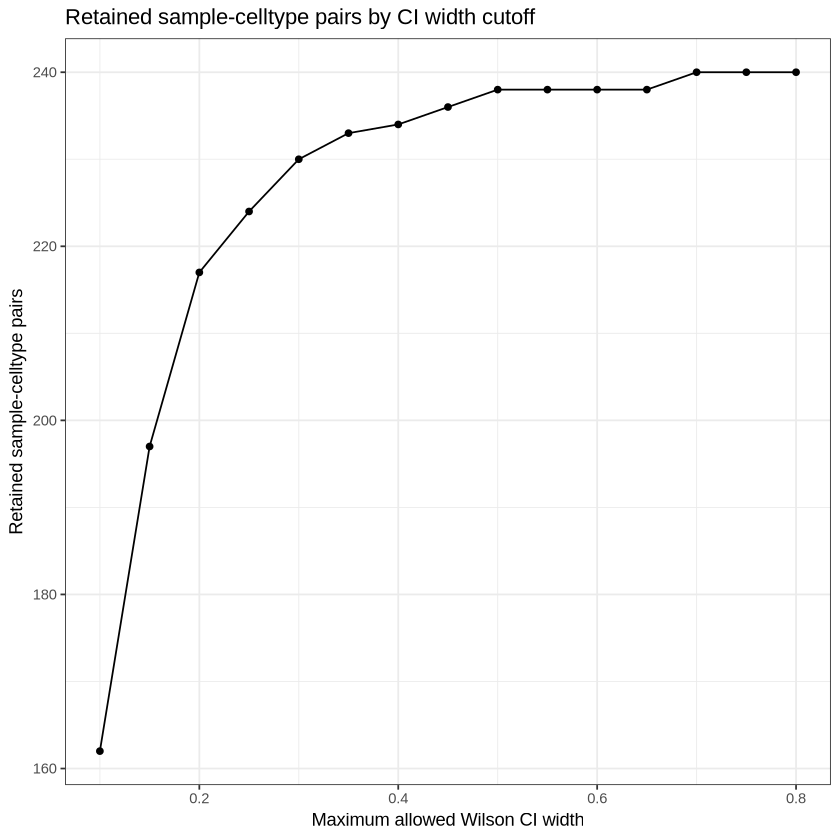

In [ ]:
unique(summary_table$sample_id)
range(summary_table$ci_width, na.rm = TRUE)
nrow(summary_table)


ci_grid <- seq(0.0, 1.0, by = 0.05)

retention_df <- lapply(ci_grid, function(cutoff) {
  tmp <- summary_table %>%
    mutate(usable = ci_width <= cutoff)
  
  data.frame(
    max_ci_width = cutoff,
    retained_pairs = sum(tmp$usable, na.rm = TRUE),
    retained_cells = sum(tmp$n_cells[tmp$usable], na.rm = TRUE),
    retained_PLA = sum(tmp$n_PLA[tmp$usable], na.rm = TRUE)
  )
}) %>%
  bind_rows()

p_retention_current <- ggplot(retention_df, aes(x = max_ci_width, y = retained_pairs)) +
  geom_line() +
  geom_point() +
  theme_bw() +
  labs(
    title = "Retained sample-celltype pairs by CI width cutoff",
    x = "Maximum allowed Wilson CI width",
    y = "Retained sample-celltype pairs"
  )

print(p_retention_current)
ggsave(
  p_retention_current,
  filename = file.path(OUT_DIR, "01_retention_curve.png"),
  width = 6,
  height = 4
)

In [84]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_cells)

excluded_pairs <- summary_table %>%
  filter(!usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_cells)

write.csv(
  usable_pairs,
  file.path(OUT_DIR, "02_usable_sample_celltype_pairs.csv"),
  row.names = FALSE
)

write.csv(
  excluded_pairs,
  file.path(OUT_DIR, "03_excluded_sample_celltype_pairs.csv"),
  row.names = FALSE
)

In [85]:
summary_table <- summary_table %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype_id = as.character(celltype_id)
  )

sample_order <- summary_table %>%
  group_by(sample_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_PLA)) %>%
  pull(sample_id)

celltype_order <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(total_PLA) %>%
  pull(celltype_id)

plot_df <- summary_table %>%
  complete(
    sample_id = sample_order,
    celltype_id = celltype_order,
    fill = list(
      n_cells = NA_integer_,
      n_PLA = NA_integer_,
      n_platelet_free = NA_integer_,  
      freq_PLA = NA_real_,
      ci_width = NA_real_,
      enough_precision = FALSE,
      enough_cells = FALSE,
      usable_celltype_sample = FALSE
    )
  ) %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order),
    celltype_id = factor(celltype_id, levels = celltype_order),
    freq_PLA_plot = ifelse(usable_celltype_sample, freq_PLA, NA_real_),
    label_fraction = case_when(
      is.na(n_cells) ~ "NA",
      !enough_precision & !enough_cells ~ "unstable\nlow n",
      !enough_precision ~ "unstable",
      !enough_cells ~ "low n",
      usable_celltype_sample ~ paste0(round(freq_PLA * 100, 1), "%"),
      TRUE ~ ""
    )
  )

In [86]:
head(dataset)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,sample,donor_id,cell_barcodes,scRNA.seq,TCR,⋯,seurat_clusters,RNA_snn_res.0.25,RNA.weight,ADT.weight,leiden_0.8_totalVI,leiden_0.25_totalVI,celltype_full,lineage,pla_status,celltype
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<fct>,<chr>,<chr>
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,GSM8571042_Abd-S111,2613,1041,1050,160,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,1,1,⋯,0,0,0.97098270,0.0290173,0,0,non-T cell/ non NK cell,Unassigned,NA,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,GSM8571042_Abd-S111,5223,1471,1021,159,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,1,1,⋯,0,0,0.08052634,0.9194737,1,0,neutrophils,neutrophils,NA,Neutrophils
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,GSM8571042_Abd-S111,4243,1395,396,113,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,1,1,⋯,1,1,0.28554898,0.7144510,4,2,R11,Unassigned,NA,Unassigned (R11)
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,GSM8571042_Abd-S111,5729,1994,985,160,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,1,1,⋯,0,0,0.83490856,0.1650914,0,0,non-T cell/ non NK cell,Unassigned,NA,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042_Abd-S111,7899,2114,772,140,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,1,1,⋯,4,4,0.73354394,0.2664561,9,3,platelet free B cells,B cells,platelet-free,B cells
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042_Abd-S111,5756,1892,404,114,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,1,1,⋯,2,2,0.59590352,0.4040965,2,1,platelet free cd4 t cells,CD4 T cells,platelet-free,CD4 T cells
GSM8571042_Abd-S111_AAACCTGGTATAGGGC-1,GSM8571042_Abd-S111,3080,1419,598,141,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTATAGGGC-1,1,1,⋯,0,0,0.21371779,0.7862822,0,0,non-T cell/ non NK cell,Unassigned,NA,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGGTGACTACT-1,GSM8571042_Abd-S111,3711,1622,788,148,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTGACTACT-1,1,1,⋯,2,2,0.63032031,0.3696797,2,1,pla CD8 T cells,CD8 T cells,PLA,CD8 T cells
GSM8571042_Abd-S111_AAACCTGGTGCCTGCA-1,GSM8571042_Abd-S111,7506,2276,1276,168,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTGCCTGCA-1,1,1,⋯,0,0,0.51350908,0.4864909,0,0,non B cell/non T cell/ non monocyte,Unassigned,NA,Non-B / Non-T / Non-monocyte cells


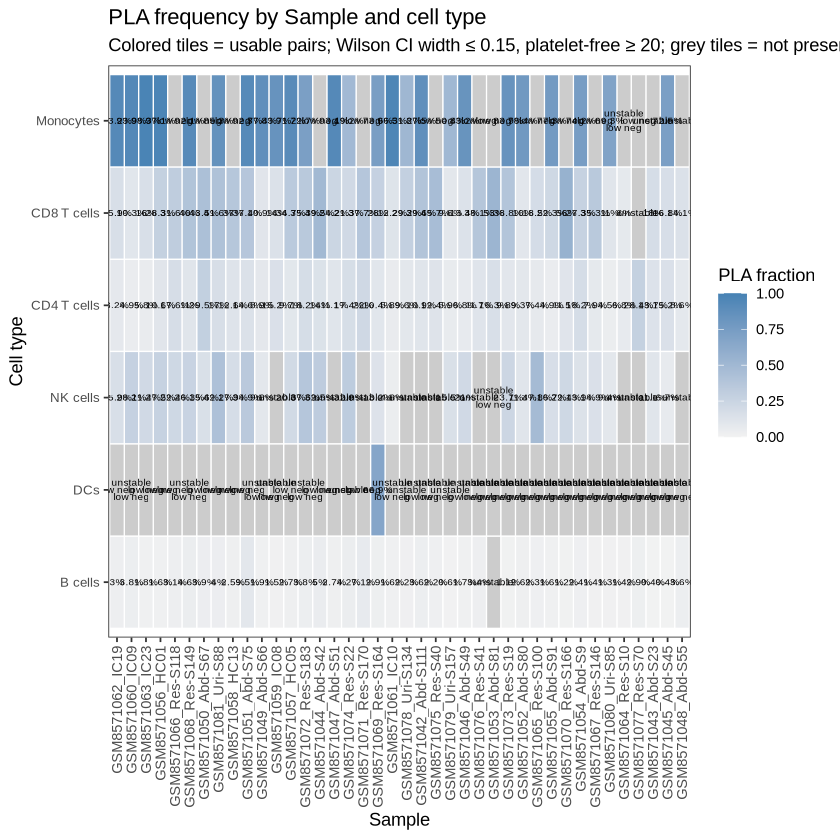

In [87]:
plot_width <- max(10, length(sample_order) * 0.35)
plot_height <- max(7, length(celltype_order) * 0.28)

p_heat <- ggplot(plot_df, aes(x = sample_id, y = celltype_id, fill = freq_PLA_plot)) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = label_fraction), size = 2.1) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    limits = c(0, 1),
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y = element_text(size = 8)
  ) +
  labs(
    title = paste0("PLA frequency by ", sample_label, " and cell type"),
    subtitle = paste0(
      "Colored tiles = usable pairs; Wilson CI width ≤ ", max_ci_width,
      ", cells per pair ≥ ", min_cells_per_pair,
      "; grey tiles = not present or not usable"
    ),
    x = "Sample",
    y = "Cell type",
    fill = "PLA fraction"
  )

print(p_heat)

ggsave(
  file.path(OUT_DIR, "04_PLA_frequency_by_sample_celltype_filtered.png"),
  p_heat,
  width = plot_width,
  height = plot_height,
  dpi = 300
)

In [88]:
qc_overview <- summary_table %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    unstable_pairs = sum(!enough_precision, na.rm = TRUE),
    low_cell_pairs = sum(!enough_cells, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    total_cells = sum(n_cells, na.rm = TRUE),
    total_PLA = sum(n_PLA, na.rm = TRUE),
    retained_cell_fraction = retained_cells / total_cells,
    retained_PLA_fraction = retained_PLA / total_PLA
  )

print(qc_overview)
write.csv(qc_overview, file.path(OUT_DIR, "05_qc_filter_overview.csv"), row.names = FALSE)

# A tibble: 1 × 10
  total_pairs usable_pairs unstable_pairs low_neg_pairs retained_cells
        <int>        <int>          <int>         <int>          <int>
1         240          173             43            50         129839
# ℹ 5 more variables: retained_PLA <int>, total_cells <int>, total_PLA <int>,
#   retained_cell_fraction <dbl>, retained_PLA_fraction <dbl>


In [89]:
usable_by_celltype <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    usable_samples = n_distinct(sample_id[usable_celltype_sample]),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_celltype, n = Inf)
write.csv(usable_by_celltype, file.path(OUT_DIR, "06_usable_by_celltype.csv"), row.names = FALSE)

# A tibble: 6 × 7
  celltype_id total_pairs usable_pairs usable_samples retained_cells
  <chr>             <int>        <int>          <int>          <int>
1 Monocytes            40           25             25          20431
2 CD8 T cells          40           39             39          26762
3 CD4 T cells          40           40             40          50729
4 NK cells             40           29             29          10395
5 B cells              40           39             39          21220
6 DCs                  40            1              1            302
# ℹ 2 more variables: retained_PLA <int>, mean_freq_PLA_usable <dbl>


In [90]:
usable_by_sample <- summary_table %>%
  group_by(sample_id) %>%
  summarise(
    total_celltypes = n(),
    usable_celltypes = sum(usable_celltype_sample, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_sample, n = Inf)
write.csv(usable_by_sample, file.path(OUT_DIR, "07_usable_by_sample.csv"), row.names = FALSE)

# A tibble: 40 × 6
   sample_id        total_celltypes usable_celltypes retained_cells retained_PLA
   <chr>                      <int>            <int>          <int>        <int>
 1 GSM8571062_IC19                6                5           5997         2204
 2 GSM8571060_IC09                6                5           5493         2142
 3 GSM8571063_IC23                6                5           6750         2000
 4 GSM8571056_HC01                6                5           6092         1715
 5 GSM8571068_Res-…               6                5           3629         1588
 6 GSM8571081_Uri-…               6                5           3157         1435
 7 GSM8571049_Abd-…               6                5           3310         1313
 8 GSM8571059_IC08                6                4           3357         1209
 9 GSM8571051_Abd-…               6                5           2502         1198
10 GSM8571057_HC05                6                5           5448         1178
11 GSM857

In [91]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id)

meta_usable <- meta %>%
  semi_join(usable_pairs, by = c("sample_id", "celltype_id"))

usable_cells <- meta_usable$cell_id

dataset_usable <- subset(dataset, cells = usable_cells)

saveRDS(
  dataset_usable,
  file.path(OUT_DIR, "dataset_usable_sample_celltype_pairs.rds")
)

saveRDS(
  summary_table,
  file.path(OUT_DIR, "sample_celltype_frequency_QC_table.rds")
)